# Q-Axis Inductance Measurement

Step-response method: phases V and W driven in opposite directions, phase U at midpoint.  
Extracts per-phase resistance R and Q-axis inductance L_q from the RL time constant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('q-axis-inductance.csv', skiprows=5)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

            Unnamed: 0 Unnamed: 1 var:/global/fDcVoltage  \
0             Datetime   Time [s]             fDcVoltage   
1  2026-06-07 14:10:49        0.0     12.440505981445312   
2  2026-06-07 14:10:49      1e-05     12.455696105957031   
3  2026-06-07 14:10:49      2e-05     12.455696105957031   
4  2026-06-07 14:10:49      3e-05     12.455696105957031   

  var:/global/uDTC/uDTC[0] var:/global/uDTC/uDTC[1] var:/global/uDTC/uDTC[2]  \
0                  uDTC[0]                  uDTC[1]                  uDTC[2]   
1                   1374.0                   1492.0                   1255.0   
2                   1374.0                   1492.0                   1255.0   
3                   1374.0                   1492.0                   1255.0   
4                   1374.0                   1492.0                   1255.0   

  var:/global/fCurrent/fCurrent[0] var:/global/fCurrent/fCurrent[1]  \
0                      fCurrent[0]                      fCurrent[1]   
1               

In [2]:
ARR = 2749

# Map Scrutiny full-path column headers to short names by signal name
signal_map = {
    'fDcVoltage':   'v_dc',
    'uDTC[0]':      'dtc0',
    'uDTC[1]':      'dtc1',
    'uDTC[2]':      'dtc2',
    'fCurrent[0]':  'i0',
    'fCurrent[1]':  'i1',
    'fCurrent[2]':  'i2',
}
rename = {'Unnamed: 0': 'datetime', 'Unnamed: 1': 'time_s'}
for col in df.columns:
    sig = col.split('/')[-1]
    if sig in signal_map:
        rename[col] = signal_map[sig]

df_clean = df.iloc[1:].reset_index(drop=True).rename(columns=rename)

for col in ['time_s', 'v_dc', 'dtc0', 'dtc1', 'dtc2', 'i0', 'i1', 'i2']:
    df_clean[col] = pd.to_numeric(df_clean[col])

df_clean['duty0'] = df_clean['dtc0'] / ARR
df_clean['duty1'] = df_clean['dtc1'] / ARR
df_clean['duty2'] = df_clean['dtc2'] / ARR

# Phase voltages referenced to DC midpoint: V_ph = (duty - 0.5) * V_dc
df_clean['U_u'] = (df_clean['duty0'] - 0.5) * df_clean['v_dc']
df_clean['U_v'] = (df_clean['duty1'] - 0.5) * df_clean['v_dc']
df_clean['U_w'] = (df_clean['duty2'] - 0.5) * df_clean['v_dc']

print(df_clean[['time_s', 'v_dc', 'dtc1', 'duty1', 'U_u', 'U_v', 'U_w']].head(10))
print(f"\nPhase voltage stats:")
print(df_clean[['U_u', 'U_v', 'U_w']].describe())


    time_s       v_dc    dtc1     duty1       U_u       U_v       U_w
0  0.00000  12.440506  1492.0  0.542743 -0.002263  0.531742 -0.540793
1  0.00001  12.455696  1492.0  0.542743 -0.002265  0.532392 -0.541454
2  0.00002  12.455696  1492.0  0.542743 -0.002265  0.532392 -0.541454
3  0.00003  12.455696  1492.0  0.542743 -0.002265  0.532392 -0.541454
4  0.00004  12.455696  1492.0  0.542743 -0.002265  0.532392 -0.541454
5  0.00005  12.470886  1492.0  0.542743 -0.002268  0.533041 -0.542114
6  0.00006  12.470886  1492.0  0.542743 -0.002268  0.533041 -0.542114
7  0.00007  12.470886  1492.0  0.542743 -0.002268  0.533041 -0.542114
8  0.00008  12.486076  1492.0  0.542743 -0.002271  0.533690 -0.542774
9  0.00009  12.486076  1492.0  0.542743 -0.002271  0.533690 -0.542774

Phase voltage stats:
               U_u          U_v          U_w
count  1170.000000  1170.000000  1170.000000
mean     -0.002259     1.203814    -1.212852
std       0.000012     0.668661     0.668624
min      -0.002279     0.531

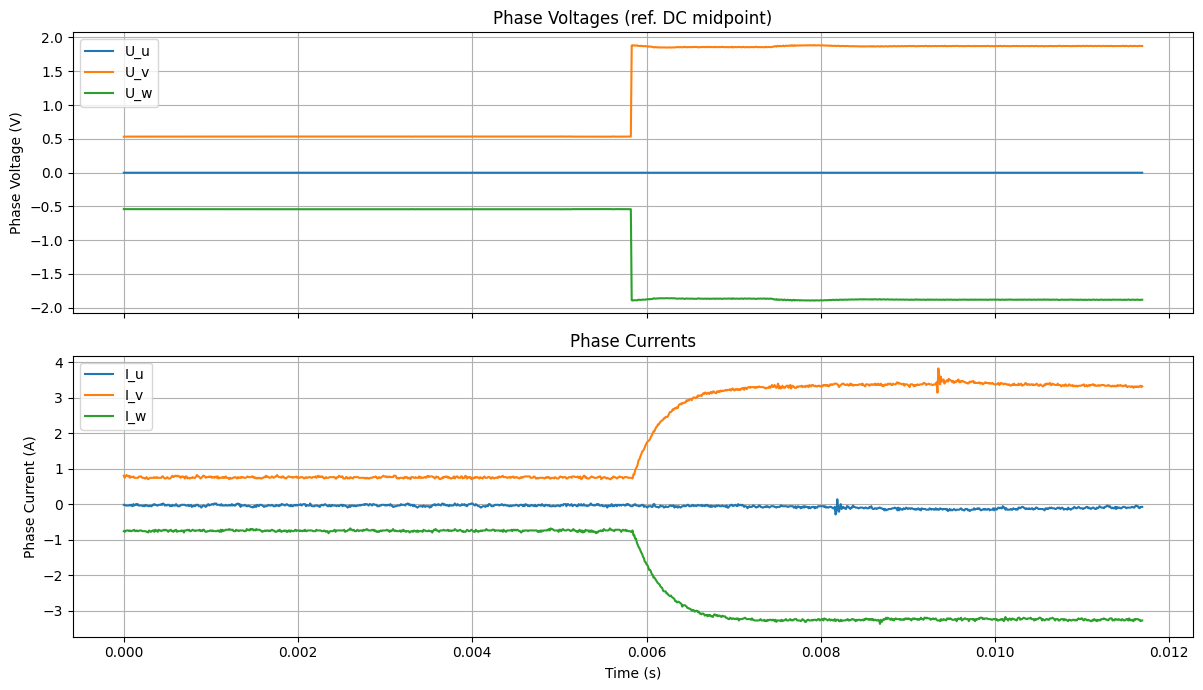

In [3]:
t = df_clean['time_s']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(t, df_clean['U_u'], label='U_u')
ax1.plot(t, df_clean['U_v'], label='U_v')
ax1.plot(t, df_clean['U_w'], label='U_w')
ax1.set_ylabel('Phase Voltage (V)')
ax1.set_title('Phase Voltages (ref. DC midpoint)')
ax1.legend()
ax1.grid(True)

ax2.plot(t, df_clean['i0'], label='I_u')
ax2.plot(t, df_clean['i1'], label='I_v')
ax2.plot(t, df_clean['i2'], label='I_w')
ax2.set_ylabel('Phase Current (A)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Phase Currents')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Step detected at t = 0.005830 s (row 583)

Fit:  Δi = 2.6183 A  (±0.0022)
      τ  = 0.3738 ms  (±0.0024)
      ΔU_line = 2.6745 V

=== Phase Parameters ===
  R = 510.734 mΩ
  L_q = 190.901 µH


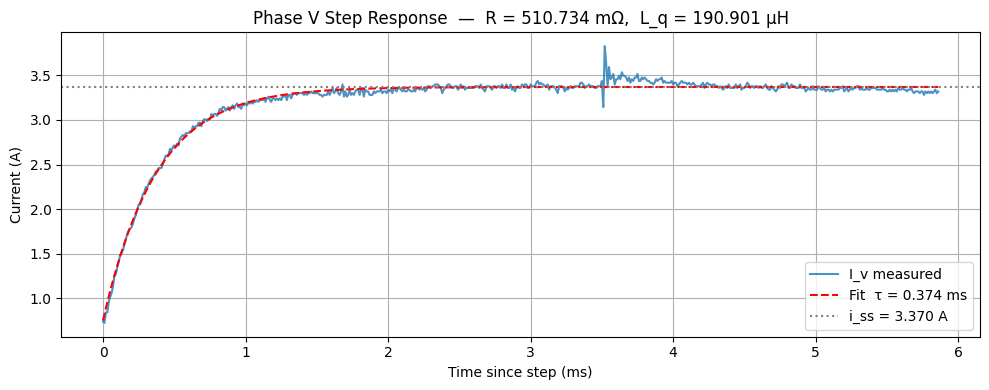

In [4]:
from scipy.optimize import curve_fit

# ── Step detection ────────────────────────────────────────────────────────────
step_idx = df_clean['U_v'].diff().abs().idxmax()
t_step   = df_clean.loc[step_idx, 'time_s']
print(f"Step detected at t = {t_step:.6f} s (row {step_idx})")

# ── Pre / post windows ────────────────────────────────────────────────────────
PRE_PTS  = 20
df_pre   = df_clean.iloc[max(0, step_idx - PRE_PTS) : step_idx]
df_post  = df_clean.loc[step_idx:]

U_line_pre  = (df_pre['U_v']  - df_pre['U_w']).mean()
U_line_post = (df_post['U_v'] - df_post['U_w']).mean()
delta_U_line = U_line_post - U_line_pre

i_pre = df_pre['i1'].mean()

# ── Exponential fit on phase-V current ────────────────────────────────────────
# Model: i(t) = i_pre + Δi·(1 − exp(−t/τ))
def exp_rise(t, delta_i, tau):
    return i_pre + delta_i * (1.0 - np.exp(-t / tau))

t_fit = (df_post['time_s'] - t_step).values
i_fit = df_post['i1'].values

delta_i_guess = i_fit[-1] - i_pre
tau_guess     = t_fit[-1] / 5

popt, pcov = curve_fit(exp_rise, t_fit, i_fit,
                       p0=[delta_i_guess, tau_guess],
                       maxfev=10000)
delta_i_fit, tau_fit = popt
perr = np.sqrt(np.diag(pcov))

# ── Parameter extraction ──────────────────────────────────────────────────────
# Y-connected motor, neutral floating, i_u ≈ 0:
#   U_v − U_w = 2·R·i_v + 2·L·di_v/dt
#   → R = (1/2)·ΔU_line / Δi   (steady state)
#   → L = τ · R
R_phase = 0.5 * delta_U_line / delta_i_fit
L_phase = tau_fit * R_phase

print(f"\nFit:  Δi = {delta_i_fit:.4f} A  (±{perr[0]:.4f})")
print(f"      τ  = {tau_fit*1e3:.4f} ms  (±{perr[1]*1e3:.4f})")
print(f"      ΔU_line = {delta_U_line:.4f} V")
print(f"\n=== Phase Parameters ===")
print(f"  R = {R_phase*1e3:.3f} mΩ")
print(f"  L_q = {L_phase*1e6:.3f} µH")

# ── Plot: measured vs fitted ──────────────────────────────────────────────────
t_dense  = np.linspace(t_fit[0], t_fit[-1], 1000)
i_model  = exp_rise(t_dense, *popt)
i_ss_abs = i_pre + delta_i_fit

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_fit * 1e3,   i_fit,   label='I_v measured', alpha=0.8)
ax.plot(t_dense * 1e3, i_model, 'r--', label=f'Fit  τ = {tau_fit*1e3:.3f} ms')
ax.axhline(i_ss_abs, color='gray', linestyle=':', label=f'i_ss = {i_ss_abs:.3f} A')
ax.set_xlabel('Time since step (ms)')
ax.set_ylabel('Current (A)')
ax.set_title(f'Phase V Step Response  —  R = {R_phase*1e3:.3f} mΩ,  L_q = {L_phase*1e6:.3f} µH')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()